### Bayesian observers
Run the cells top to bottom; edit the `👈` values and re-run.

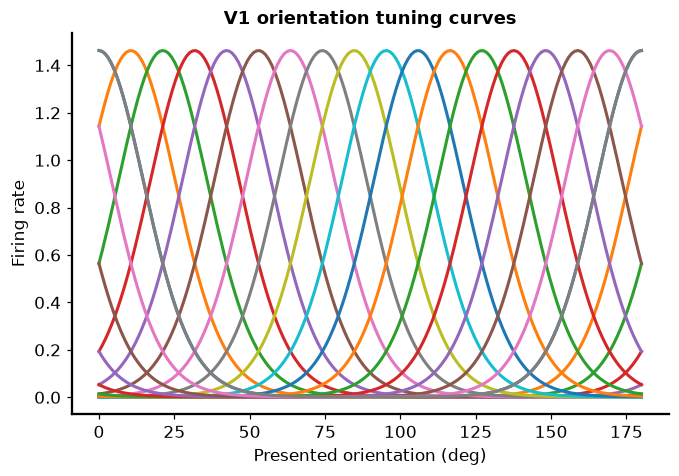

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import scipy.special as spsc

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# von Mises tuning curve (x, mu in radians)
def vmdist(x, kappa, mu):
    return (1 / (np.pi * spsc.i0(kappa))) * np.exp(kappa * np.cos(2 * (x - mu)))

# Pretend V1 has some neurons tuned to orientations spread across 0-180 deg.
nneurons = 18          # 👈 number of neurons
kappa    = 3.65        # 👈 tuning width (FWHM ~70 deg)
v1mus = np.linspace(0, np.pi, nneurons)
oris  = np.linspace(0, np.pi, 180)
v1fr  = np.array([vmdist(oris, kappa, mu) for mu in v1mus])

fig, ax = plt.subplots(figsize=(7, 4.5))
for ni in range(nneurons):
    ax.plot(oris * 180/np.pi, v1fr[ni], lw=2)
ax.set(xlabel="Presented orientation (deg)", ylabel="Firing rate",
       title="V1 orientation tuning curves")
plt.show()


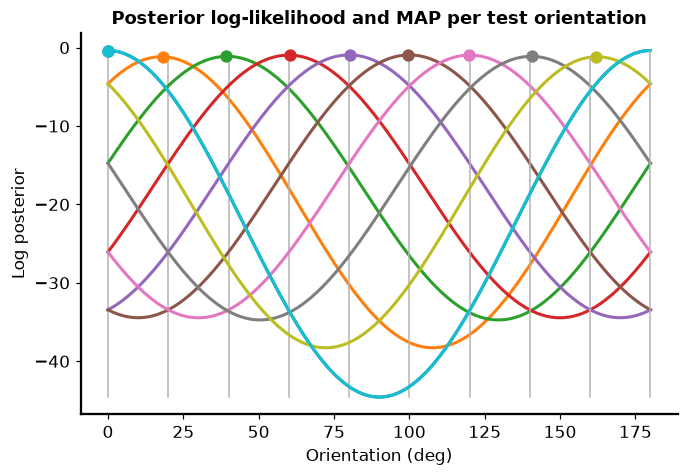

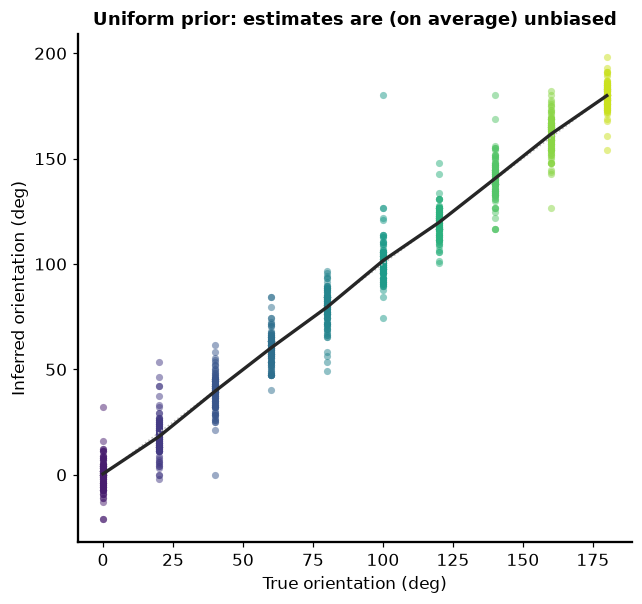

In [2]:
# The (expected) posterior log-likelihood over orientations, for some test orientations.
ntest = 10             # 👈 number of test orientations
test_oris = np.linspace(0, np.pi, ntest)

# log-likelihood = sum over neurons of (mean firing rate to test) x log(tuning curve)
meanPost = np.sum([np.log(v1fr) * vmdist(t, kappa, v1mus)[:, None] for t in test_oris], axis=1)
meanMAP  = oris[np.argmax(meanPost, axis=1)]      # maximum a posteriori estimate

fig, ax = plt.subplots(figsize=(7, 4.5))
for oi in range(ntest):
    ax.plot(oris * 180/np.pi, meanPost[oi], lw=2)
    ax.scatter(meanMAP[oi] * 180/np.pi, meanPost[oi].max(), 50, zorder=3)
    ax.plot([test_oris[oi]*180/np.pi]*2, [meanPost.min(), meanPost[oi].max()], "0.7", lw=1)
ax.set(xlabel="Orientation (deg)", ylabel="Log posterior",
       title="Posterior log-likelihood and MAP per test orientation")
plt.show()

# simulate MAP orientation estimates over many presentations
def simMAP(test_oris, oris, v1mus, kappa, v1fr, prior, nsim):
    ntest = test_oris.shape[0]
    MAP = np.zeros((ntest, nsim))
    for ti in range(ntest):
        post = np.zeros((nsim, oris.size))
        for ni in range(v1mus.shape[0]):
            fr = vmdist(test_oris[ti], kappa, v1mus[ni])            # mean firing rate
            counts = sps.poisson.rvs(fr, size=(nsim, 1))           # noisy spike counts
            post += counts * np.log(v1fr[ni]) + np.log(prior)
        MAP[ti] = oris[np.argmax(post, axis=1)]
    return MAP


def unwrap_deg(est, ref, period=180):
    # nearest circular representation of est to ref (orientation wraps every 180 deg)
    return ref + ((est - ref + period / 2) % period) - period / 2


def plot_true_vs_inferred(ax, test_oris, MAP, title, cmap="viridis"):
    ntest, nsim = MAP.shape
    means = np.zeros(ntest)
    cols = plt.get_cmap(cmap)(np.linspace(0.08, 0.92, ntest))   # gradient by orientation
    for ti in range(ntest):
        true_deg = test_oris[ti] * 180 / np.pi
        est_deg = unwrap_deg(MAP[ti] * 180 / np.pi, true_deg)   # plot near the true value
        ax.scatter(np.full(nsim, true_deg), est_deg, 22, color=cols[ti],
                   alpha=0.5, linewidths=0)
        means[ti] = est_deg.mean()
    ax.plot([0, 180], [0, 180], "0.75", ls=":", lw=1)           # identity line
    ax.plot(test_oris * 180 / np.pi, means, color="0.15", lw=2.2)
    ax.set(xlabel="True orientation (deg)", ylabel="Inferred orientation (deg)", title=title)

# simulate with a uniform (uninformative) prior
prior = np.ones(180) / 180
nsim  = 100            # 👈 simulations per test orientation
MAP = simMAP(test_oris, oris, v1mus, kappa, v1fr, prior, nsim)

fig, ax = plt.subplots(figsize=(6.5, 6))
plot_true_vs_inferred(ax, test_oris, MAP, "Uniform prior: estimates are (on average) unbiased")
plt.show()
